In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
df = pd.read_csv("C:/Users/punee/OneDrive/Downloads/diabetes_dataset.csv")

In [32]:
print(df.head())

    age  gender ethnicity education_level  income_level employment_status  \
0  58.0    Male     Asian      Highschool  Lower-Middle          Employed   
1  48.0  Female     White      Highschool        Middle          Employed   
2  60.0    Male  Hispanic      Highschool        Middle        Unemployed   
3  74.0  Female     Black      Highschool           Low           Retired   
4  46.0    Male     White        Graduate        Middle           Retired   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   
2          Never                             1   
3          Never                             0   
4          Never                             1   

   physical_activity_minutes_per_week  diet_score  ...  glucose_fasting  \
0                                 215         5.7  ...              136   
1                                 143         6.7  ...               93   
2          

In [33]:
print(df.shape)

(100000, 34)


In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 95000 non-null   float64
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [35]:
print(df.describe())

                age  alcohol_consumption_per_week  \
count  95000.000000                 100000.000000   
mean      50.131779                      2.003670   
std       15.602281                      1.417779   
min       18.000000                      0.000000   
25%       39.000000                      1.000000   
50%       50.000000                      2.000000   
75%       61.000000                      3.000000   
max       90.000000                     10.000000   

       physical_activity_minutes_per_week     diet_score  sleep_hours_per_day  \
count                       100000.000000  100000.000000        100000.000000   
mean                           119.153700       5.994787             6.997818   
std                             91.192155       1.780954             1.094622   
min                              0.000000       0.000000             3.000000   
25%                             57.000000       4.800000             6.300000   
50%                            100.0

In [36]:
print(df.isnull().sum())

age                                    5000
gender                                    0
ethnicity                                 0
education_level                           0
income_level                              0
employment_status                         0
smoking_status                            0
alcohol_consumption_per_week              0
physical_activity_minutes_per_week        0
diet_score                                0
sleep_hours_per_day                       0
screen_time_hours_per_day                 0
family_history_diabetes                   0
hypertension_history                      0
cardiovascular_history                    0
bmi                                    5000
waist_to_hip_ratio                        0
systolic_bp                               0
diastolic_bp                              0
heart_rate                                0
cholesterol_total                         0
hdl_cholesterol                           0
ldl_cholesterol                 

In [37]:
df.drop(['patient_tracking_id',
         'data_entry_notes',
         'experimental_peptide_level'],
         axis=1,
         inplace=True)

In [57]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [58]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [40]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

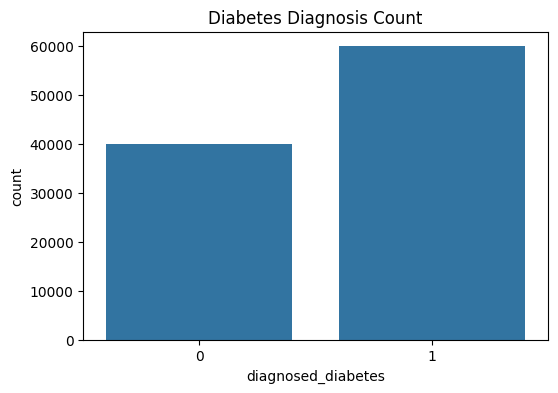

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title('Diabetes Diagnosis Count')
plt.show()

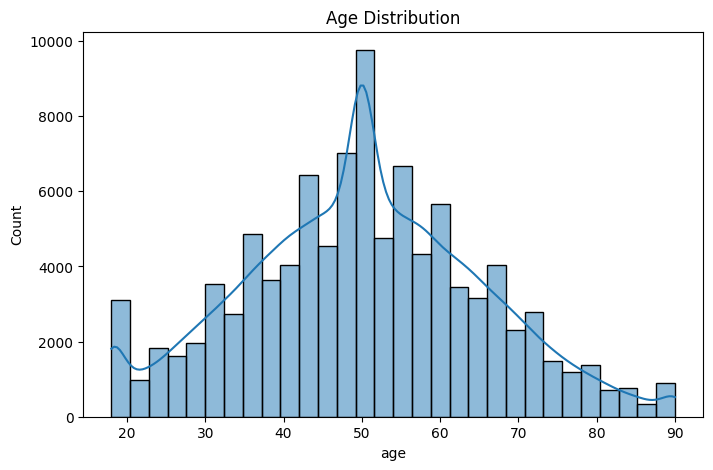

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

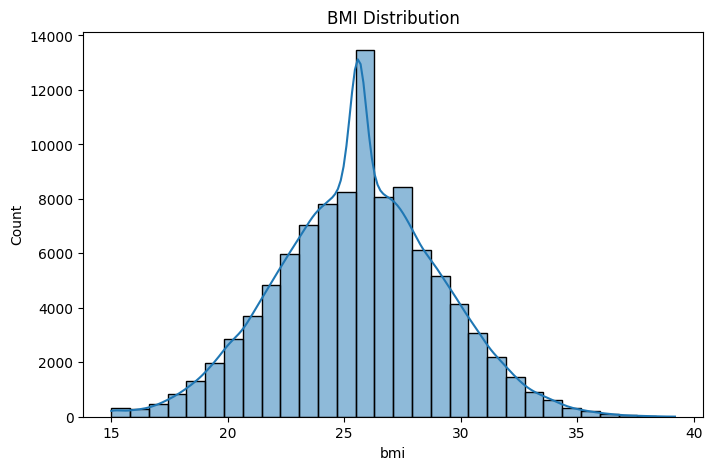

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.show()

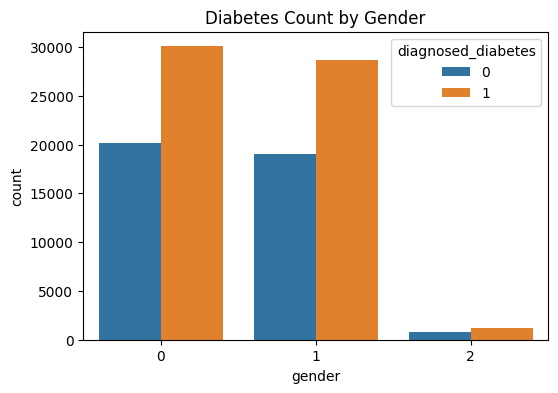

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='diagnosed_diabetes', data=df)
plt.title('Diabetes Count by Gender')
plt.show()

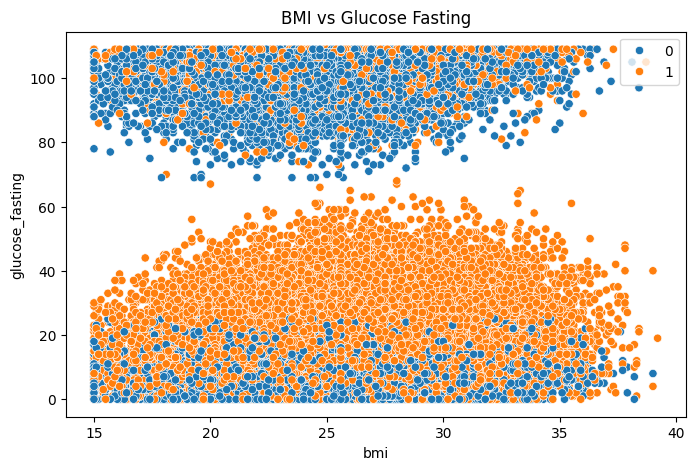

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='bmi',
    y='glucose_fasting',
    hue='diagnosed_diabetes',
    data=df
)

plt.legend(loc='upper right')
plt.title('BMI vs Glucose Fasting')
plt.show()

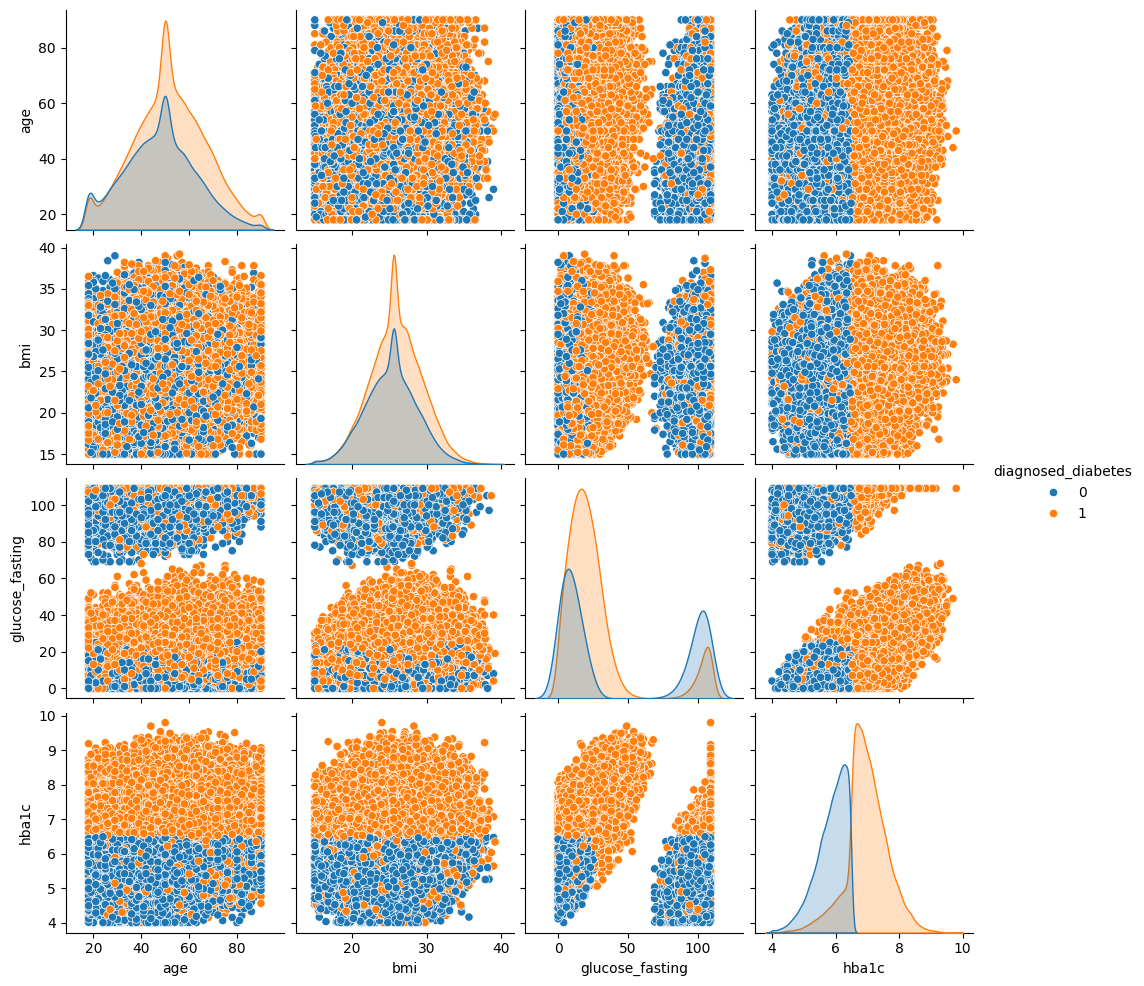

In [46]:
sns.pairplot(df[['age', 'bmi', 'glucose_fasting', 'hba1c', 'diagnosed_diabetes']],
             hue='diagnosed_diabetes')
plt.show()

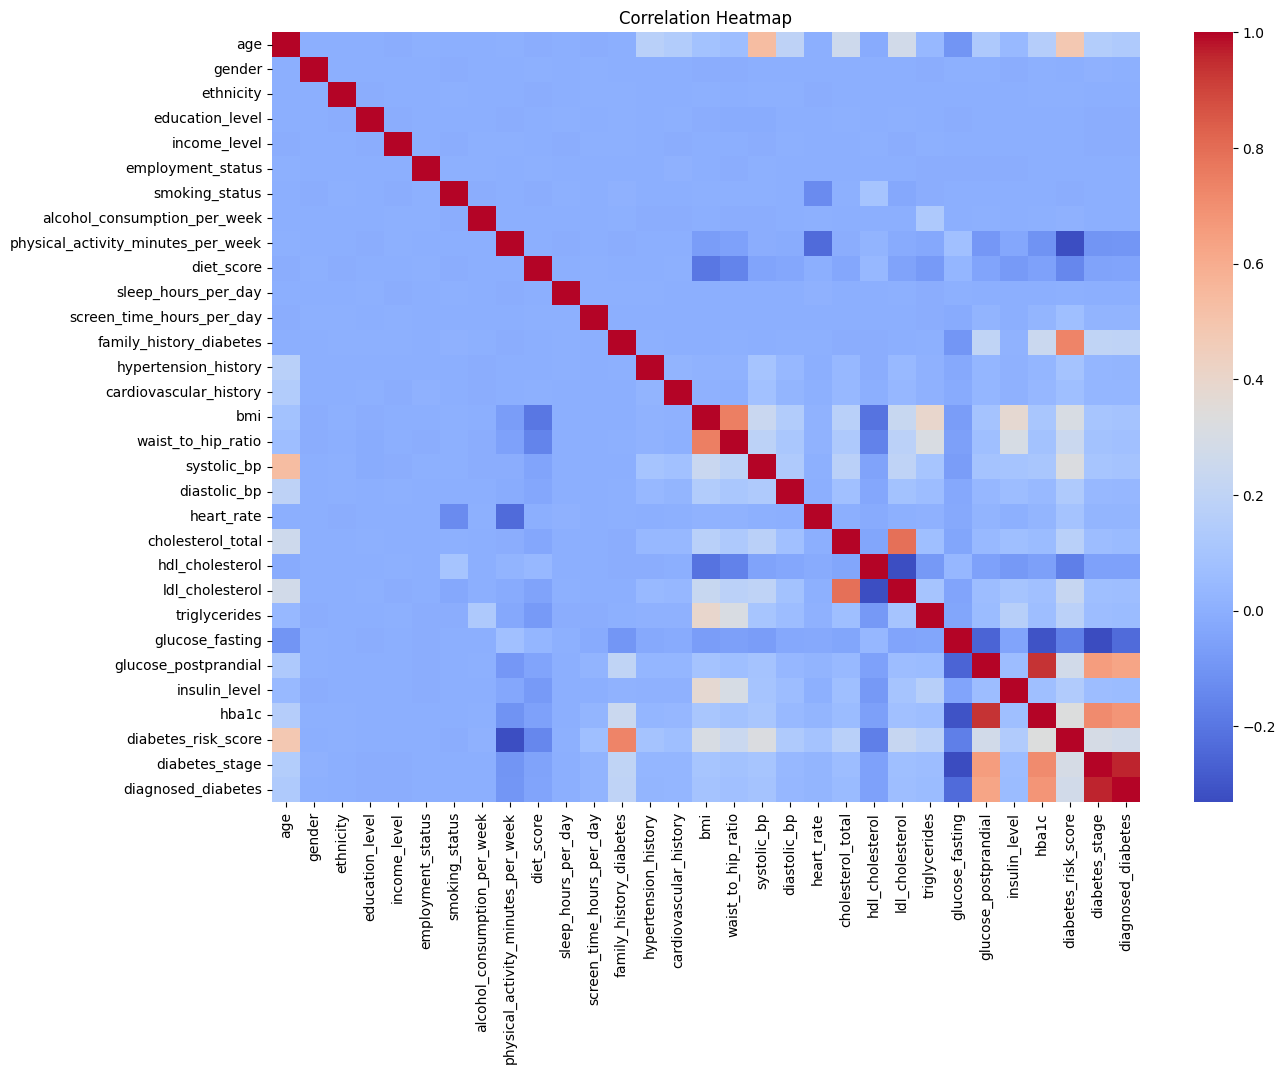

In [47]:
plt.figure(figsize=(14,10))
correlation = df.corr()
sns.heatmap(correlation, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

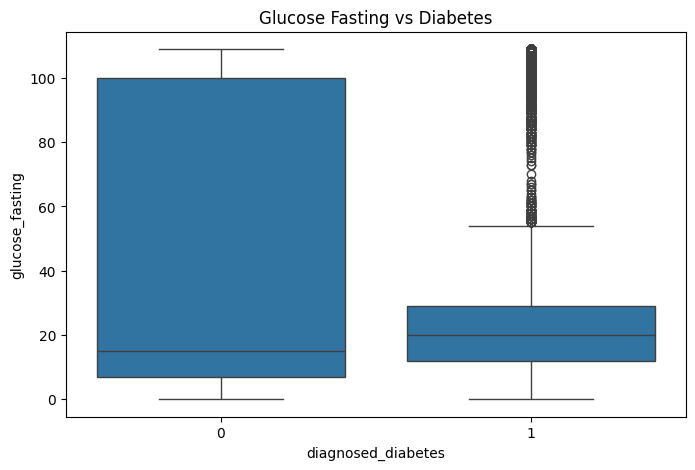

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='diagnosed_diabetes', y='glucose_fasting', data=df)
plt.title('Glucose Fasting vs Diabetes')
plt.show()

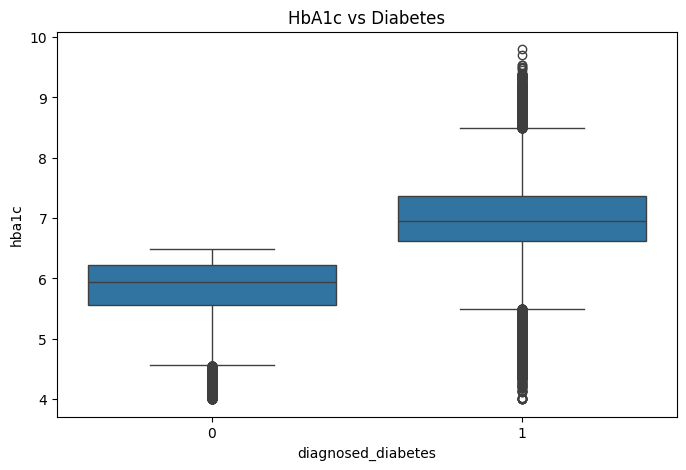

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='diagnosed_diabetes', y='hba1c', data=df)
plt.title('HbA1c vs Diabetes')
plt.show()

In [50]:
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [52]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred = model.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.99965


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8077
           1       1.00      1.00      1.00     11923

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



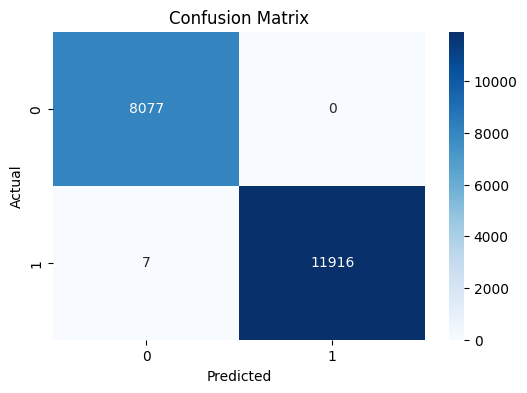

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Conclusion

This project focused on predicting diabetes using machine learning techniques. The dataset was first preprocessed by handling missing values, removing unnecessary columns, encoding categorical data, and checking for duplicate records. Exploratory Data Analysis (EDA) and multiple visualizations were performed to better understand the relationships between important health factors such as age, BMI, glucose levels, and HbA1c.

A Random Forest model was used for training and testing because it is simple, efficient, and provides good performance for classification problems. The dataset was divided into training and testing sets, and the model was evaluated using accuracy score, classification report, and confusion matrix.

The results showed that medical attributes like glucose fasting level, HbA1c, and BMI have a strong impact on diabetes prediction. The model achieved good prediction accuracy, demonstrating that machine learning can effectively help in early diabetes detection and analysis.